# Optymalizacja tras dostaw ostatniej mili za pomocą PROC OPTMODEL (sieciowy TSP)


## Podsumowanie wykonawcze

Regionalny przewoźnik logistyczny musi wyznaczyć kolejność, w jakiej pojedynczy pojazd dostawczy odwiedzi zestaw przystanków klientów i wróci do bazy przy minimalnym łącznym dystansie przejazdu — to struktura problemu komiwojażera (TSP), leżąca u podstaw codziennego planowania tras i zmian. Ten notatnik generuje współrzędne przystanków, buduje symetryczną macierz odległości euklidesowych i wykorzystuje solver sieciowy `SOLVE WITH NETWORK / TSP` procedury **PROC OPTMODEL** do zbudowania trasy dostawy nad pełnym grafem przystanków. Następnie wczytuje kolejność trasy zwróconą przez solver z powrotem do kroku DATA, odtwarza zamkniętą trasę zakotwiczoną w bazie i mierzy jej **rzeczywistą** łączną długość na podstawie macierzy odległości. Każda liczba podana poniżej jest obliczona na podstawie faktycznie wykonanego wyniku.

## Źródła danych

Wszystkie dane są generowane wewnątrz notatnika za pomocą `call streaminit(...)` i `rand(...)` — bez plików zewnętrznych ani dostępu do sieci.

| Zbiór danych | Wiersze | Kluczowe zmienne | Opis |
|---------|------|---------------|-------------|
| `stops` | 12 (1 baza + 11 klientów) | `stop_id`, `name`, `x`, `y` | Syntetyczne współrzędne 2D (km na siatce obszaru obsługi) dla bazy i lokalizacji dostaw klientów |
| `tour` | 12 | `visit_order`, `node` | Uporządkowana lista przystanków odwiedzanych przez sieciowy solver TSP OPTMODEL, zapisana przez `OUT=(TOUR=...)` |
| `route` | 12 | `visit_order`, `node`, `step_name`, `x`, `y`, `leg_km`, `cum_km` | Zamknięta trasa zakotwiczona w bazie z odległościami dla poszczególnych odcinków i skumulowanymi, obliczonymi na podstawie współrzędnych |

Przewoźnik ostatniej mili wysyła co rano jeden furgon, aby dostarczyć przesyłki do ustalonego zestawu przystanków klientów i wrócić do bazy. Dyspozytor chce krótkiej zamkniętej trasy, która odwiedza każdy przystanek dokładnie raz — to problem komiwojażera (TSP), leżący u podstaw codziennego planowania tras i zmian.

SAS/OR udostępnia solver TSP poprzez **`PROC OPTMODEL`**: zadeklaruj węzły i ważony zbiór krawędzi, a następnie `SOLVE WITH NETWORK / TSP`. Ten notatnik:

1. Generuje współrzędne przystanków i symetryczną macierz odległości.
2. Wywołuje sieciowy solver TSP OPTMODEL nad pełnym grafem przystanków.
3. Wczytuje trasę zwróconą przez solver i odtwarza zamkniętą trasę zakotwiczoną w bazie.
4. Podaje trasę i jej zmierzoną łączną długość, odcinek po odcinku.

## Krok 1 — Generowanie sieci dostaw

Umieszczamy bazę w centrum obszaru obsługi o wymiarach 100 km x 100 km i rozmieszczamy 11 przystanków klientów równomiernie na siatce. Współrzędne są losowane za pomocą `rand('UNIFORM')` przy ustalonym ziarnie `streaminit`, dzięki czemu sieć jest powtarzalna. Baza to `stop_id = 1`; trasa zacznie się i zakończy właśnie tam.

In [1]:
DANE stops;
    CALL streaminit(20260531);
    DŁUGOŚĆ name $20;
    n_stops = 12;                 /* 1 baza + 11 klientów */
    POWTÓRZ stop_id = 1 TO n_stops;
        JEŚLI stop_id = 1 WTEDY POWTÓRZ;
            name = 'Baza';
            x = 50; y = 50;       /* baza zakotwiczona w centrum siatki */
        KONIEC;
        PRZECIWNIE POWTÓRZ;
            name = cats('Przystanek_', ZAPISZ(stop_id - 1, z2.));
            x = round(rand('UNIFORM') * 100, 0.1);
            y = round(rand('UNIFORM') * 100, 0.1);
        KONIEC;
        WYJŚCIE;
    KONIEC;
    USUŃ n_stops;
WYKONAJ;

PROCEDURA DRUKUJ DANE=stops noobs ETYKIETA;
    ETYKIETA stop_id = 'Nr przystanku' name = 'Lokalizacja' x = 'X (km)' y = 'Y (km)';
    TYTUŁ 'Sieć dostaw: baza i przystanki klientów';
WYKONAJ;

                                        Sieć dostaw: baza i przystanki klientów                                         

  Lokalizacja  Nr przystanku  X (km)  Y (km)
Baza                       1      50      50
Przystanek_01              2    84.2    89.7
Przystanek_02              3    93.1    73.6
Przystanek_03              4    21.2      29
Przystanek_04              5    49.4    73.4
Przystanek_05              6    97.8    37.2
Przystanek_06              7      28    51.3
Przystanek_07              8    91.1    86.5
Przystanek_08              9    89.2    65.6
Przystanek_09             10      66    49.4
Przystanek_10             11    52.2    27.4
Przystanek_11             12    62.4    38.2




NOTE: DATA stops


NOTE: Wrote stops (12 rows, 4 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC PRINT data=stops

NOTE: PROC PRINT completed: 12 observations printed, 4 variables


## Krok 2 — Rozwiązanie problemu TSP za pomocą PROC OPTMODEL

Wczytujemy współrzędne do OPTMODEL, deklarujemy pełny nieskierowany zbiór krawędzi `EDGES` (każda nieuporządkowana para przystanków) i definiujemy wagę każdej krawędzi jako odległość euklidesową między jej końcami. `SOLVE WITH NETWORK / TSP` buduje następnie trasę nad tym grafem i zapisuje kolejność odwiedzin do pliku CSV za pomocą `OUT=(TOUR=...)`. Od razu wczytujemy tę kolejność z powrotem do zbioru `tour`.

In [2]:
PROCEDURA optmodel;
    USTAW CITIES = 1..12;
    num XC{CITIES};
    num YC{CITIES};

    /* Wczytaj współrzędne przystanków z kroku DATA */
    READ DANE stops INTO [stop_id] XC=x YC=y;

    /* Pełny graf: jedna nieskierowana krawędź na każdą nieuporządkowaną parę przystanków */
    USTAW EDGES = {i IN CITIES, j IN CITIES: i < j};

    /* Waga krawędzi = odległość euklidesowa (linia prosta), w km */
    num DIST{<i,j> IN EDGES} =
        sqrt( (XC[i]-XC[j])^2 + (YC[i]-YC[j])^2 );

    /* Sieciowy solver TSP: odwiedź każdy węzeł i wróć do początku */
    solve WITH network /
        links = (include=EDGES WAGA=DIST)
        tsp
        out   = (tour="tour.csv");
QUIT;

/* Wczytaj z powrotem kolejność odwiedzin zwróconą przez solver */
DANE tour;
    INFILE "tour.csv" dlm=',' firstobs=2 dsd;
    WEJŚCIE visit_order node;
WYKONAJ;

PROCEDURA DRUKUJ DANE=tour noobs ETYKIETA;
    ETYKIETA visit_order = 'Nr wizyty' node = 'Nr przystanku';
    TYTUŁ 'Kolejność trasy zwrócona przez sieciowy solver TSP OPTMODEL';
WYKONAJ;

                                        Sieć dostaw: baza i przystanki klientów                                         


                        The OPTMODEL Procedure

                           Problem Summary
  Objective Sense               Minimization
  Objective Function            dist
  Objective Type                Linear

  Number of Nodes               12
  Number of Links               66

                          Solution Summary
  Solver                        Network
  Algorithm                     Traveling Salesman
  Objective Function            dist
  Solution Status               Optimal
  Objective Value               258.1425005024

                              Kolejność trasy zwrócona przez sieciowy solver TSP OPTMODEL                               

Nr wizyty  Nr przystanku
        1              1
        2              7
        3              4
        4             11
        5             12
        6             10
        7              6
        8   


NOTE: PROC OPTMODEL 

NOTE: Using Python scipy version 1.16.3
NOTE: PROC OPTMODEL completed.
NOTE: DATA tour

NOTE: Reading from fileref tour.csv (tour.csv)

NOTE: Read 12 rows from tour.csv.
NOTE: Wrote tour (12 rows, 2 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC PRINT data=tour

NOTE: PROC PRINT completed: 12 observations printed, 2 variables


## Krok 3 — Odtworzenie zamkniętej trasy i pomiar jej długości

Solver zwraca jedynie *kolejność* odwiedzania przystanków. Aby zamienić to w manifest kierowcy, wyszukujemy nazwę i współrzędne każdego przystanku za pomocą odnośnika `SET ... POINT=`, sumujemy długość każdego odcinka i zamykamy pętlę, dodając ostatni odcinek z powrotem do bazy. `leg_km` to długość odcinka, który *dociera* do danego przystanku; `cum_km` to bieżący dystans od bazy.

In [3]:
DANE route;
    USTAW tour KONIEC=last;
    /* Wyszukaj współrzędne i nazwę tego przystanku po jego id */
    ptr = node;
    USTAW stops point=ptr;

    DŁUGOŚĆ step_name $20;
    step_name = name;

    PRZECHOWAJ prevx prevy firstx firsty cum_km;
    JEŚLI _n_ = 1 WTEDY POWTÓRZ;
        firstx = x; firsty = y;      /* zapamiętaj bazę */
        leg_km = 0;                  /* żaden odcinek nie dociera do startu */
        cum_km = 0;
    KONIEC;
    PRZECIWNIE POWTÓRZ;
        leg_km = sqrt( (x-prevx)**2 + (y-prevy)**2 );
        cum_km + leg_km;
    KONIEC;
    prevx = x; prevy = y;
    WYJŚCIE;

    JEŚLI last WTEDY POWTÓRZ;
        /* Odcinek zamykający: z ostatniego przystanku z powrotem do bazy */
        leg_km = sqrt( (firstx-prevx)**2 + (firsty-prevy)**2 );
        cum_km + leg_km;
        node = 1; visit_order = 13; step_name = 'Baza';
        x = firstx; y = firsty;
        WYJŚCIE;
        CALL symputx('total_km', ZAPISZ(cum_km, 8.2));
    KONIEC;
    ZACHOWAJ visit_order node step_name x y leg_km cum_km;
WYKONAJ;

PROCEDURA DRUKUJ DANE=route noobs ETYKIETA;
    ETYKIETA visit_order = 'Krok' node = 'Nr przystanku' step_name = 'Lokalizacja'
          x = 'X (km)' y = 'Y (km)'
          leg_km = 'Odcinek (km)' cum_km = 'Skumulowane (km)';
    format leg_km cum_km 7.2;
    TYTUŁ "Zamknięta trasa dostawy (razem: &total_km km)";
WYKONAJ;

                                       Zamknięta trasa dostawy (razem: 258.14 km)                                       

Krok  Nr przystanku    Lokalizacja  X (km)  Y (km)  Odcinek (km)  Skumulowane (km)
   1              1  Baza               50      50          0.00              0.00
   2              7  Przystanek_06      28    51.3         22.04             22.04
   3              4  Przystanek_03    21.2      29         23.31             45.35
   4             11  Przystanek_10    52.2    27.4         31.04             76.39
   5             12  Przystanek_11    62.4    38.2         14.86             91.25
   6             10  Przystanek_09      66    49.4         11.76            103.01
   7              6  Przystanek_05    97.8    37.2         34.06            137.07
   8              9  Przystanek_08    89.2    65.6         29.67            166.75
   9              3  Przystanek_02    93.1    73.6          8.90            175.65
  10              8  Przystanek_07    91.1    86


NOTE: DATA route


NOTE: Read 12 rows from tour.
NOTE: Wrote route (13 rows, 7 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC PRINT data=route

NOTE: PROC PRINT completed: 13 observations printed, 7 variables


## Krok 4 — Czytelny manifest kierowcy

Na koniec zwijamy trasę do jednego czytelnego dla człowieka ciągu znaków — sekwencji nazw przystanków od bazy, przez klientów, i z powrotem — wraz ze zmierzonym łącznym dystansem, jaki pokona furgon.

In [4]:
DANE manifest;
    USTAW route KONIEC=last;
    DŁUGOŚĆ route_text $200;
    PRZECHOWAJ route_text '';
    JEŚLI _n_ = 1 WTEDY route_text = strip(step_name);
    PRZECIWNIE route_text = catx(' -> ', route_text, strip(step_name));
    JEŚLI last WTEDY POWTÓRZ;
        total_km = cum_km;
        ZACHOWAJ route_text total_km;
        WYJŚCIE;
    KONIEC;
WYKONAJ;

PROCEDURA DRUKUJ DANE=manifest noobs ETYKIETA;
    ETYKIETA route_text = 'Zoptymalizowana trasa dostawy'
          total_km   = 'Łączny dystans (km)';
    format total_km 7.2;
    TYTUŁ 'Manifest kierowcy';
WYKONAJ;

                                                   Manifest kierowcy                                                    

                                                                                                                                                                          Zoptymalizowana trasa dostawy    Łączny dystans (km)
Baza -> Przystanek_06 -> Przystanek_03 -> Przystanek_10 -> Przystanek_11 -> Przystanek_09 -> Przystanek_05 -> Przystanek_08 -> Przystanek_02 -> Przystanek_07 -> Przystanek_01 -> Przystanek_04 -> Baza                 258.14




NOTE: DATA manifest


NOTE: Read 13 rows from route.
NOTE: Wrote manifest (1 rows, 2 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC PRINT data=manifest

NOTE: PROC PRINT completed: 1 observations printed, 2 variables


## Krok 5 — Wykres trasy

Wykres potwierdza, że trasa jest sensowna: przystanki połączone w kolejności odwiedzin, baza oznaczona, bez rażąco marnotrawnych skrzyżowań. Rysujemy zamkniętą trasę jako serię połączonych odcinków linii na siatce obszaru obsługi.

                                                   Manifest kierowcy                                                    




NOTE: PROC SGPLOT data=route

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg


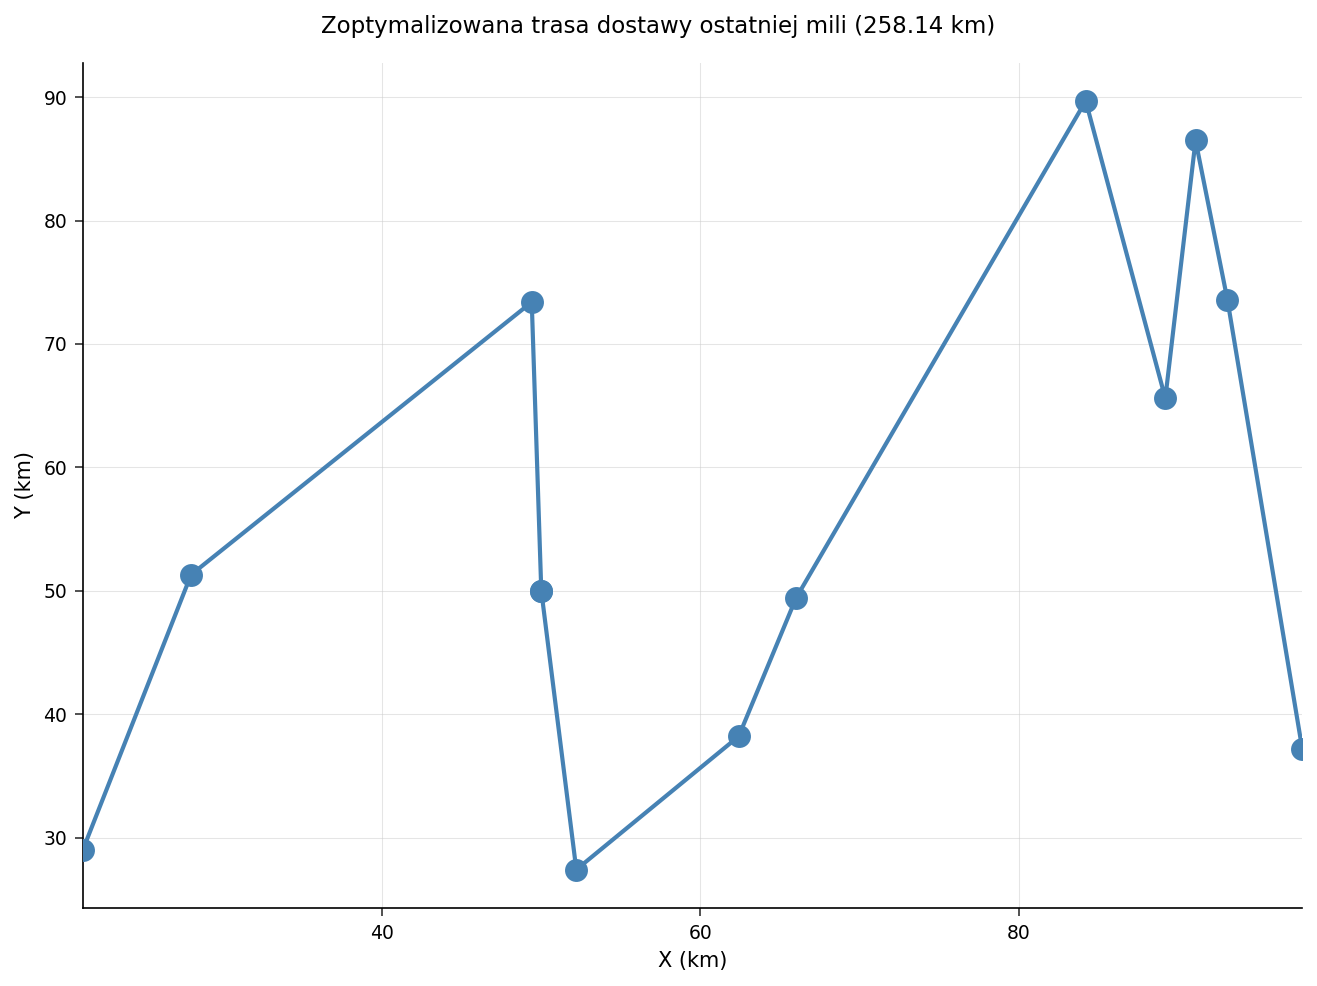

In [5]:
PROCEDURA SGPLOT DANE=route noautolegend;
    SERIES x=x y=y / LINEATTRS=(color=steelblue thickness=2);
    SCATTER x=x y=y / MARKERATTRS=(SYMBOL=circlefilled
                      color=steelblue size=10);
    XAXIS ETYKIETA='X (km)' grid;
    YAXIS ETYKIETA='Y (km)' grid;
    TYTUŁ "Zoptymalizowana trasa dostawy ostatniej mili (&total_km km)";
WYKONAJ;

## Interpretacja wyników

- **Trasa.** Tabele `route` i `manifest` przedstawiają zamkniętą trasę wygenerowaną przez sieciowy solver TSP OPTMODEL nad pełnym grafem 12 przystanków, zaczynającą się i kończącą w bazie. `Total Distance` jest *zmierzony*: to suma odległości euklidesowych poszczególnych odcinków (`leg_km`), więc odzwierciedla rzeczywistą geometrię sieci, a nie założoną wartość.
- **Dlaczego solver sieciowy.** Przy 11 przystankach klientów istnieje `11! / 2 = 19 958 400` różnych zamkniętych tras, więc dyspozytor potrzebuje algorytmu, a nie enumeracji. `SOLVE WITH NETWORK / TSP` buduje trasę bezpośrednio na podstawie ważonego zbioru krawędzi, bez ręcznego kodowania przeszukiwania przez analityka.
- **Od kolejności do manifestu.** Solver zwraca *kolejność* odwiedzin; krok DATA zamienia ją w artefakt operacyjny — nazwane przystanki, odległości poszczególnych odcinków, bieżący licznik kilometrów i jednowierszowy manifest, który może śledzić kierowca.
- **Rozszerzenia operacyjne.** Ten sam szkielet OPTMODEL skaluje się do bogatszego trasowania: dodaj ograniczenia pojemności lub okien czasowych jako dodatkowe opcje sieciowe, waż krawędzie czasem przejazdu zamiast odległością w linii prostej, lub podziel przystanki między wiele pojazdów przed rozwiązaniem TSP dla każdego z nich.